# Blackbox Optimisation Project: Phase 1.1

A purely explorative approach by looking for the most isolated point within the input domain and chosing that as the coordinate of the next point <br><br> -- A convex hull is calcualted to find the bounds of the inputs space <br> -- Random sampling is used to efficiently fill the multi-dimensional space <br> -- The random sample with the largest Euclidian distance to any of the input data point is chosen as the next point

In [1]:
week = 1
function = 1

Import Standard Libraries

In [2]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path

import matplotlib.pyplot as plt

Import Project Packages

In [3]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

### Import and Update Data

In [ ]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)
# print(f"\tloaded original data set...")

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
input_cols = data_loading.get_X_cols(df)

df_inputs = df[input_cols]
df_output = df.drop(columns=input_cols)

Requested function 1 in week 1

Data Loading
	Loaded initial data: function_1
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk2.csv
		4: new_data_point_wk3.csv
		5: new_data_point_wk4.csv
		6: new_data_point_wk5.csv
		7: new_data_point_wk6.csv
		8: new_data_point_wk7.csv
		9: new_data_point_wk8.csv
		10: new_data_point_wk9.csv
	No files found for weeks 1 to 0.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_1\function_1...

Data Preprocessing


In [6]:
print(f"\n Current Max Value: {df['Y1'].max()}")


 Current Max Value: 7.710875114502849e-16


### Augment data set

Find most isolated point in the input space, bound by the convex hull of all inputs data

In [7]:
print("Calculate Convex Hull")
hull, points = data_augmentation.compute_convex_hull(df_inputs)

print("Find most isolated point within convex hull")

best_point, best_dist = data_augmentation.most_isolated_point(points, hull, n_samples=10000, seed=42)

def to_dict(point, columns):
    return {col: val for col, val in zip(columns, point)}

best_point_dict = to_dict(best_point, input_cols)

Calculate Convex Hull
Find most isolated point within convex hull
	generating random seeds...
	finding internal points...
	looking for furthest points...


### Plot Results

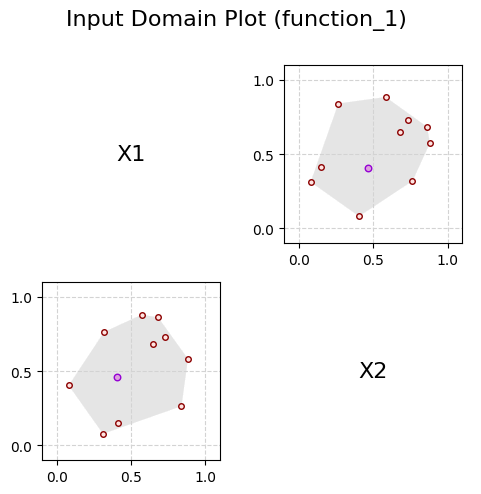

In [8]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points,hull = hull, next_point = best_point_dict)

write results to csv

In [9]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [10]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.405454-0.460896
